<a href="https://colab.research.google.com/github/shriyam943/-Unemployment-Analysis-/blob/main/Unemployment_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [ ]:
df = pd.read_csv('Unemployment in India.csv')

print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


# Dataset Information

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None


In [ ]:

print(df.describe())


       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                          10.721298        8.087988e+06   
min                           0.000000        4.942000e+04   
25%                           4.657500        1.190404e+06   
50%                           8.350000        4.744178e+06   
75%                          15.887500        1.127549e+07   
max                          76.740000        4.577751e+07   

       Estimated Labour Participation Rate (%)  
count                               740.000000  
mean                                 42.630122  
std                                   8.111094  
min                                  13.330000  
25%                                  38.062500  
50%                                  41.160000  
75%                                  45.505000  
max                                  72.570000  


In [ ]:

print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


# Data Cleaning

In [ ]:
df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

In [ ]:
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [ ]:
print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [ ]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_13646/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


# Overall Unemployment Trend

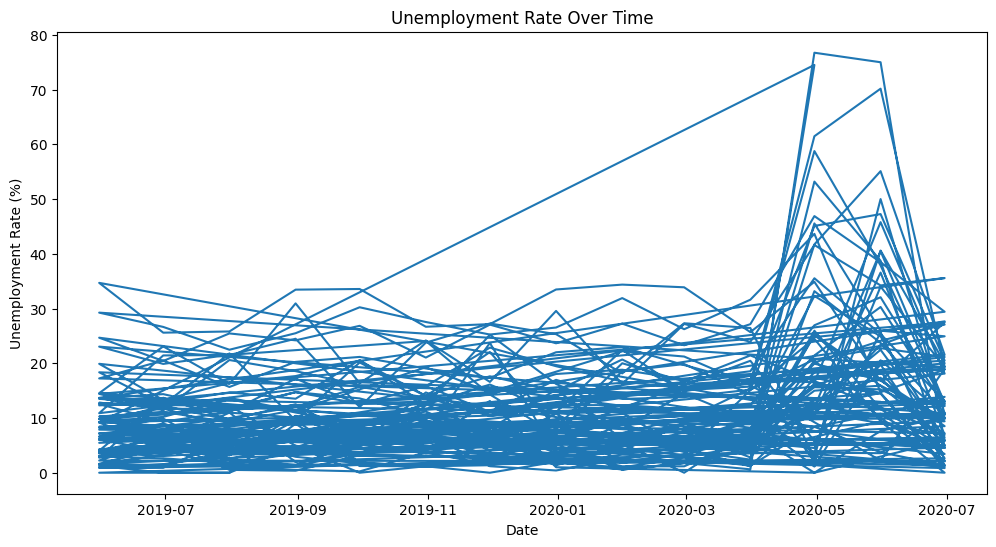

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'],
         df['Estimated Unemployment Rate (%)'])

plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.show()

# Covid-19 Impact Analysis

In [ ]:
pre_covid = df[df['Date'] < '2020-03-01']

post_covid = df[df['Date'] >= '2020-03-01']

In [ ]:
print("Pre Covid Mean:",
      pre_covid['Estimated Unemployment Rate (%)'].mean())

print("Post Covid Mean:",
      post_covid['Estimated Unemployment Rate (%)'].mean())

Pre Covid Mean: 9.509533582089553
Post Covid Mean: 17.774362745098042


# State-wise Analysis

In [ ]:
state_unemployment = df.groupby(
    'Region'
)['Estimated Unemployment Rate (%)'].mean()

state_unemployment.sort_values(
    ascending=False
).head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


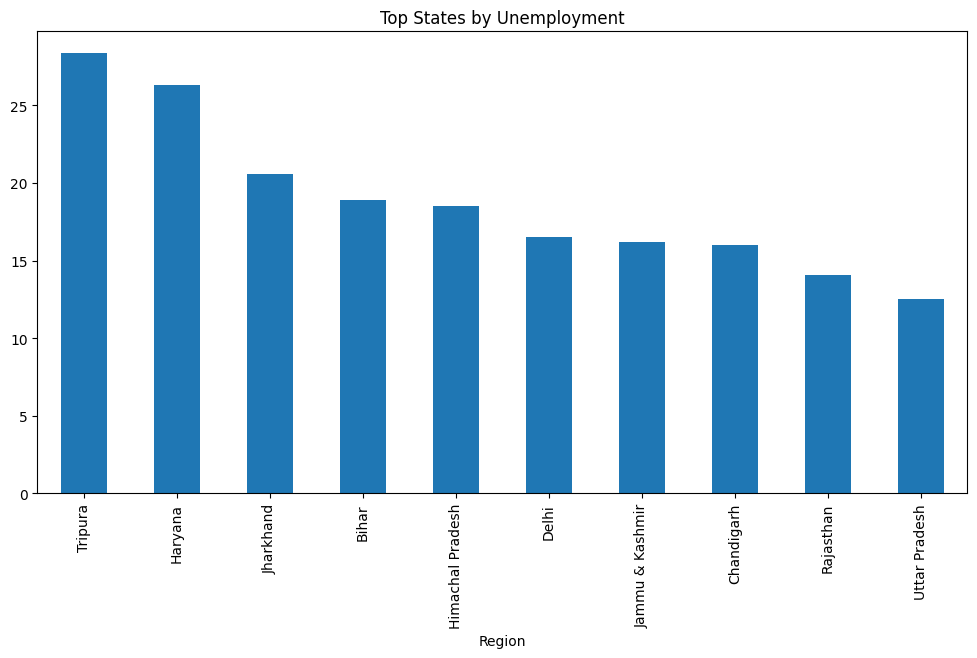

In [ ]:
plt.figure(figsize=(12,6))

state_unemployment.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title('Top States by Unemployment')
plt.show()

# Monthly Trend Analysis

In [ ]:
df['Month'] = df['Date'].dt.month

In [ ]:
monthly = df.groupby(
    'Month'
)['Estimated Unemployment Rate (%)'].mean()

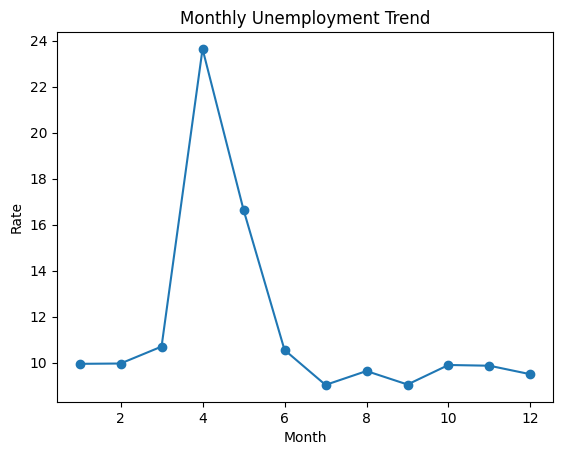

In [ ]:
monthly.plot(marker='o')

plt.title('Monthly Unemployment Trend')

plt.xlabel('Month')

plt.ylabel('Rate')

plt.show()

# Heatmap

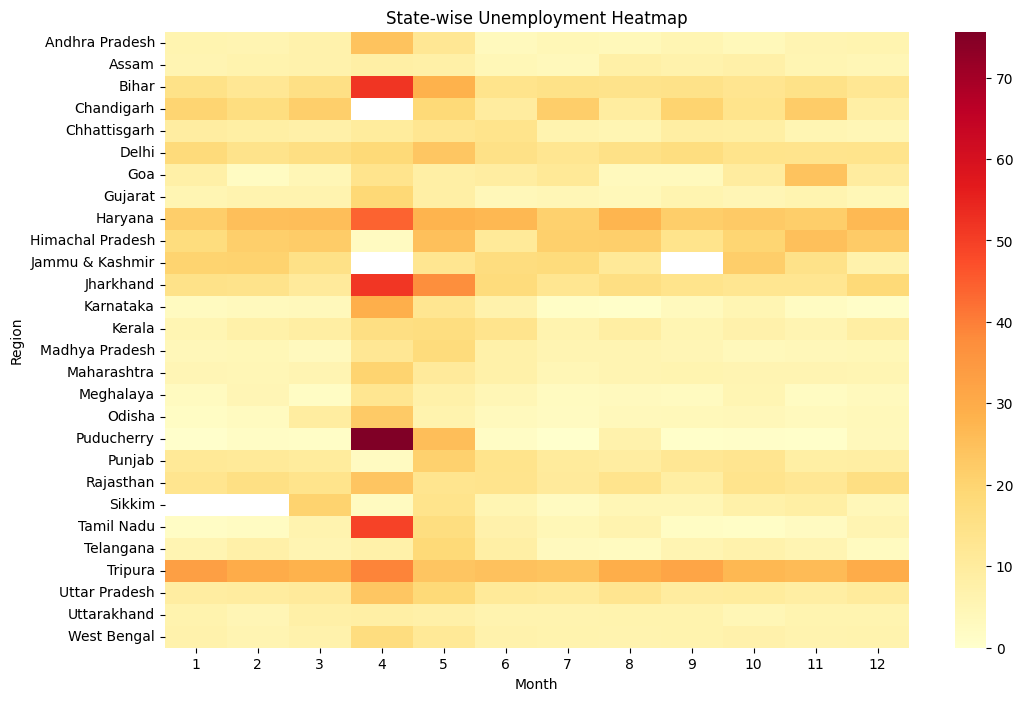

In [ ]:
pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot,
    cmap='YlOrRd'
)

plt.title('State-wise Unemployment Heatmap')

plt.show()